In [1]:
import numpy as np
import subprocess
import itertools
import re
from scipy.interpolate import RegularGridInterpolator
import astropy.units as u
from astropy.io import fits
from synphot import SourceSpectrum, Observation
from synphot.models import Empirical1D
import multiprocessing as mp
import emcee
import corner

from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

import os
gd_folder = os.getcwd()+"/../../Calculations/SKIRTOR/"

import sys 
sys.path.append(gd_folder)
#from loadSKIRTOR_MRN77 import LoadSKIRTOR_MRN77
from loadSKIRTOR_MRN77_force_reg import LoadSKIRTOR_MRN77
from loadSKIRTOR_General import LoadSKIRTOR_General

sys.path.append("../utility_functions/")
from objectProperties import ObjectProperties
from readExtrapolatedSpectra import ReadExtrapolatedSpectra

sys.path.append("../../Filter_Curves/")
from readBands import ReadBands

sys.path.append("../../spec_modeling/")
from model_W0116_spec import model_W0116_spec

In [2]:
def plt_contours(x, y, ax, nx=50j, ny=50j):

    # ax = plt.gca()
    # y = flatchain[:,0] #Torus
    # x = flatchain[:,1] #Cone

    # 1. Calculate 2D Kernel Density Estimate
    values = np.vstack([x,y])
    kernel = gaussian_kde(values)

    # 2. Create a grid of points
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    X, Y = np.mgrid[x_min:x_max:nx, y_min:y_max:ny]
    positions = np.vstack([X.ravel(), Y.ravel()])

    # Evaluate the density at each grid point
    Z = np.reshape(kernel(positions).T, X.shape)

    # 3. Sort flattened Z values in descending order to find the 68% threshold
    flat_z = Z.ravel()
    sorted_idx = np.argsort(flat_z)[::-1]
    sorted_z = flat_z[sorted_idx]

    # Calculate cumulative distribution of probability
    csum = np.cumsum(sorted_z)
    csum /= csum[-1]

    # Find the threshold density level for 68% (0.68)
    idx_68 = np.where(csum >= 0.683)[0][0]
    level_68 = sorted_z[idx_68]

    idx_95 = np.where(csum >= 0.954)[0][0]
    level_95 = sorted_z[idx_95]

    idx_99 = np.where(csum >= 0.991)[0][0]
    level_99 = sorted_z[idx_99]

    # 4. Plot the 68% contour
    contour = ax.contour(X, Y, Z, levels=[level_99, level_95, level_68], colors='xkcd:grey', linewidths=2)
    #ax.clabel(contour, fmt={level_68: '68%'}, inline=True)

    return
#plt.show()

In [15]:
def make_plot(flatchain, fname=None, n=50j):

   fig, axs = plt.subplots(1, 3, figsize=(12,6), layout='constrained')
   for ax in axs.flatten():
      ax.tick_params(axis='both', direction='in', labelsize=14, bottom=True, top=True, left=True, right=True)

   axis_label_fontsize = 14

   #n = 10j
   #n = 50j

   #Torus - Cone
   ax = axs[0]
   ax.set_xlim([20.,60.])
   ax.set_ylim([25.,60.])
   plt_contours(flatchain[:,1], flatchain[:,0], ax, nx=n, ny=n)
   ax.plot(ax.get_xlim(), np.array(ax.get_xlim()), 'k--') 
   ax.fill_between(ax.get_xlim(), np.array(ax.get_xlim()), ax.get_ylim()[0], color="none", hatch="xx", edgecolor="xkcd:gray", linewidth=0.0, alpha=0.3)
   ax.set_xlabel(r"Cone half-opening angle $\psi_{\rm Cone}$ (deg)", fontsize=axis_label_fontsize)
   ax.set_ylabel(r"Torus half-opening angle $\psi_{\rm Torus}$ (deg)", fontsize=axis_label_fontsize)
   x0,x1 = ax.get_xlim()
   y0,y1 = ax.get_ylim()
   ax.set_aspect(abs(x1-x0)/abs(y1-y0))
   ax.text(0.50, 0.25, "Region where \n"+r"$\psi_{\rm Cone} > \psi_{\rm Torus}$", fontsize=14, weight='extra bold', fontfamily='sans-serif', transform=ax.transAxes, wrap=True)

   #Torus - Inclination
   ax = axs[1]
   ax.set_xlim([25.,90.])
   ax.set_ylim([25.,60.])
   plt_contours(flatchain[:,2], flatchain[:,0], ax, nx=n, ny=n)
   ax.plot(ax.get_xlim(), ax.get_xlim(), 'k--') 
   ax.plot(ax.get_xlim(), -np.array(ax.get_xlim()), 'k--') 
   ax.fill_betweenx(ax.get_ylim(), -np.array(ax.get_ylim()), np.array(ax.get_ylim()), color="none", hatch="xx", edgecolor="xkcd:gray", linewidth=0.0, alpha=0.3)
   ax.set_xlabel(r"Inclination angle $\eta$ (deg)", fontsize=axis_label_fontsize)
   ax.set_ylabel(r"Torus half-opening angle $\psi_{\rm Torus}$ (deg)", fontsize=axis_label_fontsize)
   x0,x1 = ax.get_xlim()
   y0,y1 = ax.get_ylim()
   ax.set_aspect(abs(x1-x0)/abs(y1-y0))
   ax.text(0.01, 0.95, "Direct line of sight \nto accretion \ndisk", ha='left', va='top', fontsize=14, weight='extra bold', fontfamily='sans-serif', transform=ax.transAxes)

   #Cone - Inclination
   ax = axs[2]
   ax.set_xlim([25.,90.])
   ax.set_ylim([10.,60.])
   plt_contours(flatchain[:,2], flatchain[:,1], ax, nx=n, ny=n)
   ax.plot(ax.get_xlim(), np.array(ax.get_xlim()), 'k--') 
   ax.plot(ax.get_xlim(), -np.array(ax.get_xlim()), 'k--') 
   ax.fill_betweenx(ax.get_ylim(), -np.array(ax.get_ylim()), np.array(ax.get_ylim()), color="none", hatch="xx", edgecolor="xkcd:gray", linewidth=0.0, alpha=0.3)
   plt.xlabel(r"Inclination angle $\eta$ (deg)", fontsize=axis_label_fontsize)
   plt.ylabel(r"Cone half-opening angle $\psi_{\rm Cone}$ (deg)", fontsize=axis_label_fontsize)
   x0,x1 = ax.get_xlim()
   y0,y1 = ax.get_ylim()
   ax.set_aspect(abs(x1-x0)/abs(y1-y0))
   ax.text(0.01, 0.95, "Direct line of sight\n to accretion \ndisk", ha='left', va='top',fontsize=14, weight='extra bold', fontfamily='sans-serif', transform=ax.transAxes)

   #fig.colorbar(cb, fraction=0.05).set_label(label=r'Min $\chi^2$',size=18)

   plt.show()
   if fname is not None:
      fig.savefig(fname, dpi=200, bbox_inches='tight')

In [16]:
flatchain_W0116 = np.loadtxt("W0116_flatchain.txt")
flatchain_W0116_use = flatchain_W0116[flatchain_W0116[:,0]>flatchain_W0116[:,1]]

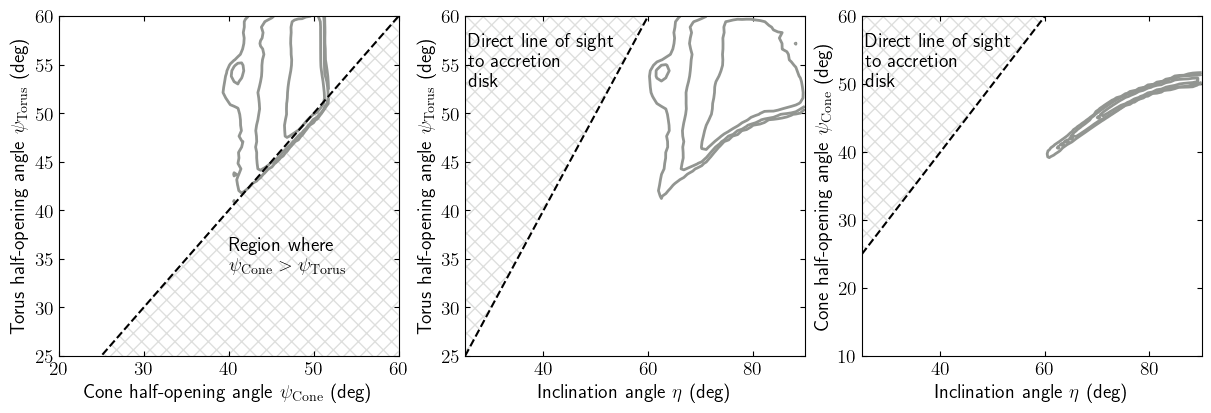

In [21]:
make_plot(flatchain_W0116_use, n=50j, fname="W0116_MCMC_contours.png")